In [ ]:
 # !pip install darts --quiet

In [ ]:
# !pip install numpy==1.26.4 pmdarima==2.0.4 --force-reinstall
# import os
# os.kill(os.getpid(), 9)

In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import torch.nn as nn
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from tensorflow.keras.utils import plot_model

# Read Data & Feature Technical


In [3]:
df = pd.read_csv('MERGE_SAHAM_GABUNGAN_FINAL.csv', parse_dates=['tanggal'])
df = df.sort_values('tanggal')
df = df.drop(columns=['Unnamed: 0'])

In [4]:
# Fitur teknikal dasar
df['return'] = df['Terakhir'].pct_change() # <- buat melihat return harian (persentase perubahan)
df['lag1_return'] = df['return'].shift(1) # <- untuk melihat pengaruh return sebelumnya terhadap return saat ini
df['ma5'] = df['Terakhir'].rolling(5).mean().shift(1) # <- membuat moving average 5 hari dari harga 'Terakhir', lalu digeser 1 hari ke belakang
df['ma10'] = df['Terakhir'].rolling(10).mean().shift(1) # <- membuat moving average 10 hari dari harga 'Terakhir', lalu digeser 1 hari ke belakang
df['volatility5'] = df['return'].rolling(5).std().shift(1) # <- menghitung volatility 5 hari terakhir dan digeser 1 hari ke belakang
df['dayofweek'] = df['tanggal'].dt.dayofweek # <- mengambil hari dalam minggu

In [5]:
df.head()

,tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,avg_sentiment,prop_pos,prop_neg,prop_neu,count,max_impact,return,lag1_return,ma5,ma10,volatility5,dayofweek
0,2022-01-03,666531.0,658626.0,667720.0,658613.0,1.826000e+10,1.27,0.000000,0.0,0.0,1.0,1.0,netral,NaN,NaN,NaN,NaN,NaN,0
1,2022-01-04,669537.0,667513.0,672066.0,667513.0,1.859000e+10,0.45,0.789194,1.0,0.0,0.0,2.0,positif,0.004510,NaN,NaN,NaN,NaN,1
2,2022-01-05,666230.0,670317.0,673811.0,663484.0,1.791000e+10,-0.49,0.000000,0.0,0.0,1.0,0.0,netral,-0.004939,0.004510,NaN,NaN,NaN,2
3,2022-01-06,665335.0,667485.0,667985.0,659323.0,1.800000e+10,-0.13,-0.646162,0.0,1.0,0.0,1.0,negatif,-0.001343,-0.004939,NaN,NaN,NaN,3
4,2022-01-07,670132.0,666951.0,671215.0,664771.0,1.571000e+10,0.72,0.500000,0.5,0.0,0.5,2.0,positif,0.007210,-0.001343,NaN,NaN,NaN,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   tanggal        722 non-null    datetime64[ns]
 1   Terakhir       722 non-null    float64       
 2   Pembukaan      722 non-null    float64       
 3   Tertinggi      722 non-null    float64       
 4   Terendah       722 non-null    float64       
 5   Vol.           722 non-null    float64       
 6   Perubahan%     722 non-null    float64       
 7   avg_sentiment  722 non-null    float64       
 8   prop_pos       722 non-null    float64       
 9   prop_neg       722 non-null    float64       
 10  prop_neu       722 non-null    float64       
 11  count          722 non-null    float64       
 12  max_impact     722 non-null    object        
 13  return         721 non-null    float64       
 14  lag1_return    720 non-null    float64       
 15  ma5            717 non-

In [7]:
df.dropna(axis=0, inplace=True) #menghapus nilai N/A

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 10 to 721
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   tanggal        712 non-null    datetime64[ns]
 1   Terakhir       712 non-null    float64       
 2   Pembukaan      712 non-null    float64       
 3   Tertinggi      712 non-null    float64       
 4   Terendah       712 non-null    float64       
 5   Vol.           712 non-null    float64       
 6   Perubahan%     712 non-null    float64       
 7   avg_sentiment  712 non-null    float64       
 8   prop_pos       712 non-null    float64       
 9   prop_neg       712 non-null    float64       
 10  prop_neu       712 non-null    float64       
 11  count          712 non-null    float64       
 12  max_impact     712 non-null    object        
 13  return         712 non-null    float64       
 14  lag1_return    712 non-null    float64       
 15  ma5            712 non-null

In [9]:
impact_mapping = {'negatif': -1, 'netral': 0, 'positif': 1}
df['max_impact_num'] = df['max_impact'].map(impact_mapping)

## **Uji ADF**

In [ ]:
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(series, name):
    print(f'Hasil Uji ADF untuk: {name}')
    # autolag='AIC' akan memilih lag terbaik secara otomatis
    result = adfuller(series, autolag='AIC')

    labels = ['ADF Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    for value, label in zip(result, labels):
        print(f'{label} : {value}')

    if result[1] <= 0.05:
        print("Kesimpulan: Data STASIONER (Siap digunakan)")
    else:
        print("Kesimpulan: Data TIDAK STASIONER (Perlu Differencing)")
    print("-" * 30)

perform_adf_test(df['Terakhir'], 'Terakhir')

Hasil Uji ADF untuk: Terakhir
ADF Statistic : -2.9901114249516625
p-value : 0.03582824510799864
#Lags Used : 4
Number of Observations Used : 707
Kesimpulan: Data STASIONER (Siap digunakan)
------------------------------


In [ ]:
perform_adf_test(df['Perubahan%'], 'Perubahan%')

Hasil Uji ADF untuk: Perubahan%
ADF Statistic : -28.245064557606888
p-value : 0.0
#Lags Used : 0
Number of Observations Used : 711
Kesimpulan: Data STASIONER (Siap digunakan)
------------------------------


In [ ]:
perform_adf_test(df['avg_sentiment'], 'avg_sentiment')

Hasil Uji ADF untuk: avg_sentiment
ADF Statistic : -24.676011019922733
p-value : 0.0
#Lags Used : 0
Number of Observations Used : 711
Kesimpulan: Data STASIONER (Siap digunakan)
------------------------------


In [ ]:
perform_adf_test(df['return'], 'return')

Hasil Uji ADF untuk: return
ADF Statistic : -28.242394387874302
p-value : 0.0
#Lags Used : 0
Number of Observations Used : 711
Kesimpulan: Data STASIONER (Siap digunakan)
------------------------------


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = df[['Pembukaan', 'Tertinggi', 'Terendah', 'Vol.', 'Perubahan%',
        'avg_sentiment', 'prop_pos', 'prop_neg', 'prop_neu', 'max_impact_num',
        'return', 'lag1_return', 'ma5', 'ma10', 'volatility5', 'dayofweek']]
y = df['Terakhir'].shift(-1)

mask = ~(X.isna().any(axis=1) | y.isna())
X_clean = X[mask]
y_clean = y[mask]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_clean, y_clean)

importance = pd.Series(model.feature_importances_, index=X_clean.columns).sort_values(ascending=False)
print(importance)

Terendah          0.528795
Tertinggi         0.328524
Pembukaan         0.111406
return            0.004003
lag1_return       0.003962
Perubahan%        0.003933
volatility5       0.003780
ma5               0.003662
ma10              0.003652
Vol.              0.003399
dayofweek         0.001435
avg_sentiment     0.001073
prop_neu          0.000865
prop_neg          0.000685
prop_pos          0.000551
max_impact_num    0.000274
dtype: float64


## OLS Result

In [ ]:
import statsmodels.api as sm

# x adalah skor sentimen dan y adalah return IHSG
X = df['avg_sentiment']
y = df['Terakhir']

# Menambahkan konstanta (beta 0)
X = sm.add_constant(X)

# Membuat model OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

# Menampilkan hasil full report
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Terakhir   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.876
Date:                Sun, 22 Feb 2026   Prob (F-statistic):             0.0494
Time:                        10:15:56   Log-Likelihood:                -8269.0
No. Observations:                 712   AIC:                         1.654e+04
Df Residuals:                     710   BIC:                         1.655e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           7.04e+05   1059.169    664.640

# Spliting data menggunakan chronological

In [10]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['Pembukaan',
                'Tertinggi',
                'Terendah',
                'Vol.',
                'avg_sentiment',
                'prop_pos',
                'prop_neg',
                'prop_neu',
                'return',
                'lag1_return',
                'ma5',
                'ma10',
                'volatility5']

df['target'] = df['Terakhir'].shift(-1)

train = df[(df['tanggal'] >= "2022-01-03") & (df['tanggal'] <= "2022-12-31")].copy()
val   = df[(df['tanggal'] >= "2023-01-03") & (df['tanggal'] <= "2023-06-30")].copy()
test  = df[(df['tanggal'] >= "2023-07-01") & (df['tanggal'] <= "2024-12-31")].copy()

# Drop NA akibat rolling & shift
train = train[feature_cols + ['target']].dropna()
val   = val[feature_cols + ['target']].dropna()
test  = test[feature_cols + ['target']].dropna()

scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(train[feature_cols])
scaler_y.fit(train[['target']])

def scale(df):
    X = pd.DataFrame(
        scaler_X.transform(df[feature_cols]),
        columns=feature_cols,
        index=df.index
    )
    y = pd.DataFrame(
        scaler_y.transform(df[['target']]),
        columns=['target_scaled'],
        index=df.index
    )
    return pd.concat([X, y], axis=1)

train_scaled = scale(train)
val_scaled   = scale(val)
test_scaled  = scale(test)


In [11]:
import numpy as np

def create_sequences(df_scaled, seq_len):
    X, y = [], []
    for i in range(seq_len, len(df_scaled)):
        X.append(
            df_scaled.iloc[i-seq_len:i]
            .drop(columns=['target_scaled'])
            .values
        )
        y.append(df_scaled['target_scaled'].iloc[i])
    return np.array(X), np.array(y)

SEQ_LEN = 1

X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_val,   y_val   = create_sequences(val_scaled,   SEQ_LEN)
X_test,  y_test  = create_sequences(test_scaled,  SEQ_LEN)


In [12]:
X_train.shape

(235, 1, 13)

In [13]:
lengths = [len(seq) for seq in X_train]
set(lengths)

{1}

# LSTM

In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import models, layers, callbacks, optimizers
import itertools
import warnings
warnings.filterwarnings('ignore')

# Set seed
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
import random
random.seed(42)

# Parameter grid
param_grid = {
    'lstm_units_1': [64, 128],        # dari 3 → 2
    'lstm_units_2': [32],             # dari 3 → 1
    'dense_units': [32, 64],          # dari 3 → 2
    'dropout_rate': [0.2],            # dari 3 → 1
    'learning_rate': [0.001, 0.0001], # tetap 2
    'batch_size': [32, 64],           # dari 3 → 2
}
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

total = len(all_combinations)
print(f"\n{'='*80}")
print(f"Total kombinasi: {total}")
print(f"{'='*80}\n")

results_list = []
n_features = X_train.shape[2]

for idx, combination in enumerate(all_combinations, 1):
    params = dict(zip(param_names, combination))

    # Progress bar
    progress = (idx / total) * 100
    filled = int(40 * idx // total)
    bar = '█' * filled + '░' * (40 - filled)
    print(f"\r[{bar}] {progress:.1f}% | Eksperimen {idx}/{total}", end='', flush=True)

    try:
        #struktur model
        model = models.Sequential([
            layers.Input(shape=(SEQ_LEN, n_features)),
            layers.Masking(),
            layers.LSTM(params['lstm_units_1'], return_sequences=True),
            layers.Dropout(params['dropout_rate']),
            layers.LSTM(params['lstm_units_2']),
            layers.Dense(params['dense_units'], activation='relu'),
            layers.Dense(1)
        ])

        model.compile(
            optimizer=optimizers.Adam(learning_rate=params['learning_rate']),
            loss='mse',
            metrics=['mae']
        )

        # Early stopping
        es = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        )

        # Training
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=params['batch_size'],
            callbacks=[es],
            verbose=0
        )

        # Prediksi
        y_pred_test = model.predict(X_test, verbose=0).flatten()
        y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_test_original = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()

        # evaluasi metrik
        mae_lstm = mean_absolute_error(y_test_original, y_pred_test_original)
        mse_lstm = mean_squared_error(y_test_original, y_pred_test_original)
        rmse_lstm = np.sqrt(mse_lstm)

        non_zero_mask = y_test_original != 0
        if non_zero_mask.sum() > 0:
            mape_lstm = np.mean(np.abs((y_test_original[non_zero_mask] - y_pred_test_original[non_zero_mask]) /
                                  y_test_original[non_zero_mask])) * 100
        else:
            mape_lstm = np.nan

        # Simpan hasil
        results_list.append({
            **params,
            'test_mae': mae_lstm,
            'test_mse': mse_lstm,
            'test_rmse': rmse_lstm,
            'test_mape': mape_lstm,
            'epochs_trained': len(history.history['loss'])
        })

    except Exception as e:
        print(f"\nError pada kombinasi {idx}: {str(e)}")
        continue

print(f"\n\n{'='*80}")

# Buat DataFrame hasil
results_df = pd.DataFrame(results_list)

# Menampilkan parameter terbaik
print("\n" + "="*80)
print("PARAMETER TERBAIK (Berdasarkan Test RMSE)")
print("="*80 + "\n")

best = results_df.nsmallest(1, 'test_rmse').iloc[0]

print("PARAMETER:")
print(f"  • LSTM Layer 1        : {int(best['lstm_units_1'])} units")
print(f"  • LSTM Layer 2        : {int(best['lstm_units_2'])} units")
print(f"  • Dense Layer         : {int(best['dense_units'])} units")
print(f"  • Dropout Rate        : {best['dropout_rate']}")
print(f"  • Learning Rate       : {best['learning_rate']}")
print(f"  • Batch Size          : {int(best['batch_size'])}")
print(f"  • Epochs Trained      : {int(best['epochs_trained'])}")

print("\nMETRIK EVALUASI:")
print(f"  • Test RMSE           : Rp {best['test_rmse']:,.0f}")
print(f"  • Test MAE            : Rp {best['test_mae']:,.0f}")
print(f"  • Test MAPE           : {best['test_mape']:.2f}%")

print("\n" + "="*80 + "\n")



Total kombinasi: 16

[████████████████████████████████████████] 100.0% | Eksperimen 16/16


PARAMETER TERBAIK (Berdasarkan Test RMSE)

PARAMETER:
  • LSTM Layer 1        : 128 units
  • LSTM Layer 2        : 32 units
  • Dense Layer         : 32 units
  • Dropout Rate        : 0.2
  • Learning Rate       : 0.0001
  • Batch Size          : 32
  • Epochs Trained      : 100

METRIK EVALUASI:
  • Test RMSE           : Rp 16,299
  • Test MAE            : Rp 12,065
  • Test MAPE           : 1.64%




In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import models, layers, callbacks, optimizers
import itertools
import warnings
warnings.filterwarnings('ignore')

# Set seed
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
import random
random.seed(42)

# Parameter grid
param_grid = {
    'lstm_units_1': [64, 128],        # dari 3 → 2
    'lstm_units_2': [32],             # dari 3 → 1
    'dense_units': [32, 64],          # dari 3 → 2
    'dropout_rate': [0.2],            # dari 3 → 1
    'learning_rate': [0.001, 0.0001], # tetap 2
    'batch_size': [32, 64],           # dari 3 → 2
}

# Generate semua kombinasi
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

total = len(all_combinations)
print(f"\n{'='*80}")
print(f"Total kombinasi: {total}")
print(f"{'='*80}\n")

results_list = []
n_features = X_train.shape[2]

# Loop semua kombinasi
for idx, combination in enumerate(all_combinations, 1):
    params = dict(zip(param_names, combination))

    # Progress bar
    progress = (idx / total) * 100
    filled = int(40 * idx // total)
    bar = '█' * filled + '░' * (40 - filled)
    print(f"\r[{bar}] {progress:.1f}% | Eksperimen {idx}/{total}", end='', flush=True)

    try:
        # Buat model
        model = models.Sequential([
            layers.Input(shape=(SEQ_LEN, n_features)),
            layers.Masking(),
            layers.LSTM(params['lstm_units_1'], return_sequences=True),
            layers.Dropout(params['dropout_rate']),
            layers.LSTM(params['lstm_units_2']),
            layers.Dense(params['dense_units'], activation='relu'),
            layers.Dense(1)
        ])

        model.compile(
            optimizer=optimizers.Adam(learning_rate=params['learning_rate']),
            loss='mse',
            metrics=['mae']
        )

        # Early stopping
        es = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        )

        # Training
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=params['batch_size'],
            callbacks=[es],
            verbose=0
        )

        # Prediksi
        y_pred_test = model.predict(X_test, verbose=0).flatten()
        y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_test_original = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()

        # Hitung metrik
        mae_lstm = mean_absolute_error(y_test_original, y_pred_test_original)
        mse_lstm = mean_squared_error(y_test_original, y_pred_test_original)
        rmse_lstm = np.sqrt(mse_lstm)

        non_zero_mask = y_test_original != 0
        if non_zero_mask.sum() > 0:
            mape_lstm = np.mean(np.abs((y_test_original[non_zero_mask] - y_pred_test_original[non_zero_mask]) /
                                  y_test_original[non_zero_mask])) * 100
        else:
            mape_lstm = np.nan

        # Simpan hasil
        results_list.append({
            **params,
            'test_mae': mae_lstm,
            'test_mse': mse_lstm,
            'test_rmse': rmse_lstm,
            'test_mape': mape_lstm,
            'epochs_trained': len(history.history['loss'])
        })

    except Exception as e:
        print(f"\nError pada kombinasi {idx}: {str(e)}")
        continue

print(f"\n\n{'='*80}")

# Buat DataFrame hasil
results_df = pd.DataFrame(results_list)

# STATISTIK UMUM
print("\n" + "="*80)
print("STATISTIK UMUM EKSPERIMEN")
print("="*80 + "\n")
print(f"Total model diuji      : {len(results_df)}")
print(f"RMSE terbaik          : Rp {results_df['test_rmse'].min():,.0f}")
print(f"RMSE terburuk         : Rp {results_df['test_rmse'].max():,.0f}")
print(f"RMSE rata-rata        : Rp {results_df['test_rmse'].mean():,.0f}")
print(f"MAE terbaik           : Rp {results_df['test_mae'].min():,.0f}")
print(f"MAPE terbaik          : {results_df['test_mape'].min():.2f}%")

# TOP 10 TERBAIK
print("\n" + "="*80)
print("TOP 10 MODEL TERBAIK (Berdasarkan Test RMSE)")
print("="*80 + "\n")

top_10 = results_df.nsmallest(10, 'test_rmse').reset_index(drop=True)

display_df = pd.DataFrame({
    'Rank': range(1, len(top_10) + 1),
    'LSTM1': top_10['lstm_units_1'].astype(int),
    'LSTM2': top_10['lstm_units_2'].astype(int),
    'Dense': top_10['dense_units'].astype(int),
    'Dropout': top_10['dropout_rate'].round(2),
    'LR': top_10['learning_rate'],
    'Batch': top_10['batch_size'].astype(int),
    'RMSE': top_10['test_rmse'].apply(lambda x: f"Rp {x:,.0f}"),
    'MAE': top_10['test_mae'].apply(lambda x: f"Rp {x:,.0f}"),
    'MAPE%': top_10['test_mape'].round(2),
    'Epochs': top_10['epochs_trained'].astype(int)
})

print(display_df.to_string(index=False))

# DETAIL MODEL TERBAIK
print("\n" + "="*80)
print("DETAIL MODEL TERBAIK (#1)")
print("="*80 + "\n")

best = top_10.iloc[0]

print("PARAMETER:")
print(f"  • LSTM Layer 1        : {int(best['lstm_units_1'])} units")
print(f"  • LSTM Layer 2        : {int(best['lstm_units_2'])} units")
print(f"  • Dense Layer         : {int(best['dense_units'])} units")
print(f"  • Dropout Rate        : {best['dropout_rate']}")
print(f"  • Learning Rate       : {best['learning_rate']}")
print(f"  • Batch Size          : {int(best['batch_size'])}")
print(f"  • Epochs Trained      : {int(best['epochs_trained'])}")

print("\nMETRIK EVALUASI:")
print(f"  • Test RMSE           : Rp {best['test_rmse']:,.0f}")
print(f"  • Test MAE            : Rp {best['test_mae']:,.0f}")
print(f"  • Test MAPE           : {best['test_mape']:.2f}%")

print("\n" + "="*80 + "\n")

# Simpan hasil
results_df.to_csv('lstm_experiment_results.csv', index=False)
print("✓ Hasil lengkap disimpan ke 'experiment_results.csv'\n")


Total kombinasi: 16

[████████████████████████████████████████] 100.0% | Eksperimen 16/16


STATISTIK UMUM EKSPERIMEN

Total model diuji      : 16
RMSE terbaik          : Rp 16,299
RMSE terburuk         : Rp 28,974
RMSE rata-rata        : Rp 18,165
MAE terbaik           : Rp 11,992
MAPE terbaik          : 1.62%

TOP 10 MODEL TERBAIK (Berdasarkan Test RMSE)

 Rank  LSTM1  LSTM2  Dense  Dropout     LR  Batch      RMSE       MAE  MAPE%  Epochs
    1    128     32     32      0.2 0.0001     32 Rp 16,299 Rp 12,065   1.64     100
    2    128     32     64      0.2 0.0001     64 Rp 16,531 Rp 11,992   1.62     100
    3    128     32     64      0.2 0.0001     32 Rp 16,712 Rp 12,274   1.66     100
    4    128     32     64      0.2 0.0010     64 Rp 16,751 Rp 12,561   1.70      60
    5     64     32     64      0.2 0.0001     64 Rp 17,100 Rp 12,530   1.70     100
    6    128     32     32      0.2 0.0010     32 Rp 17,203 Rp 12,896   1.75      57
    7    128     32     64      0.2 0.0010  

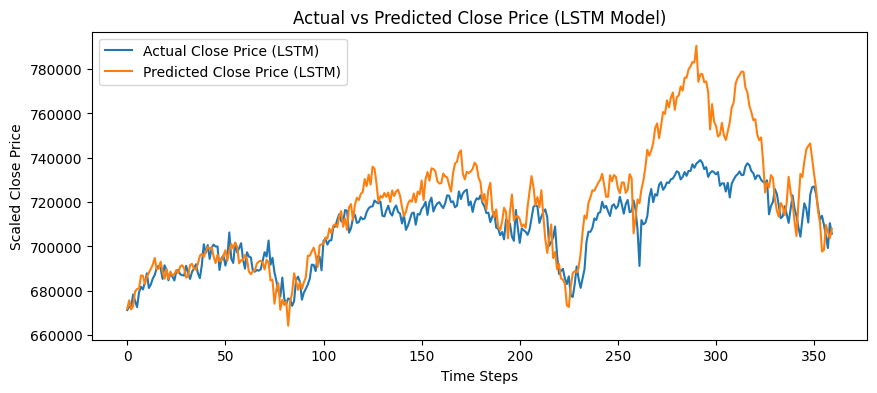

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y_pred_test_original.flatten(), label="Actual Close Price (LSTM)")
plt.plot(y_test_original.flatten(), label="Predicted Close Price (LSTM)")
plt.title("Actual vs Predicted Close Price (LSTM Model)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

# N-Beats

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from itertools import product
# Notebook — ada seed
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

def nbeats_block(x, units, input_dim, name_prefix=''):
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc1')(x)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc2')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc3')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc4')(h)
    backcast = layers.Dense(input_dim, name=f'{name_prefix}_backcast')(h)
    forecast = layers.Dense(1, name=f'{name_prefix}_forecast')(h)
    return backcast, forecast


input_dim = SEQ_LEN * len(feature_cols)
def create_nbeats_model(input_dim, units_config, learning_rate):
    inputs = layers.Input(shape=(input_dim,), name='input')

    # Block 1
    backcast1, forecast1 = nbeats_block(inputs, units=units_config[0],
                                        input_dim=input_dim, name_prefix='generic1')
    res1 = layers.Subtract(name='residual1')([inputs, backcast1])

    # Block 2
    backcast2, forecast2 = nbeats_block(res1, units=units_config[1],
                                        input_dim=input_dim, name_prefix='generic2')
    res2 = layers.Subtract(name='residual2')([res1, backcast2])

    # Block 3
    backcast3, forecast3 = nbeats_block(res2, units=units_config[2],
                                        input_dim=input_dim, name_prefix='trend1')
    res3 = layers.Subtract(name='residual3')([res2, backcast3])

    # Block 4
    backcast4, forecast4 = nbeats_block(res3, units=units_config[3],
                                        input_dim=input_dim, name_prefix='trend2')

    # Final output
    output = layers.Add(name='final_forecast')([forecast1, forecast2, forecast3, forecast4])

    model = Model(inputs=inputs, outputs=output, name='NBEATS')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )

    return model


def train_and_evaluate(X_train_flat, y_train, X_val_flat, y_val,
                       X_test_flat, y_test, scaler_y, input_dim, config):
    print(f"\n{'='*70}")
    print(f"Testing configuration: {config}")
    print(f"{'='*70}")

    # Clear session untuk menghindari memory leak
    tf.keras.backend.clear_session()

    # Create model
    model = create_nbeats_model(
        input_dim=input_dim,
        units_config=config['units'],
        learning_rate=config['learning_rate']
    )

    # Callbacks
    es = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config['patience'],
        restore_best_weights=True,
        verbose=0
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=0
    )

    # Train
    history = model.fit(
        X_train_flat, y_train,
        validation_data=(X_val_flat, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=[es, reduce_lr],
        verbose=0
    )

    # Predict
    y_pred_scaled = model.predict(X_test_flat, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))

    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Validation metrics
    val_loss = min(history.history['val_loss'])
    val_mae = min(history.history['val_mae'])

    results = {
        'config': str(config),
        'units': str(config['units']),
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'epochs': config['epochs'],
        'patience': config['patience'],
        'mae': mae,
        'rmse': rmse,
        'mse': mse,
        'mape': mape,
        'val_loss': val_loss,
        'val_mae': val_mae,
        'final_epoch': len(history.history['loss'])
    }

    print(f"Results:")
    print(f"  Test MAE  : {mae:.2f}")
    print(f"  Test RMSE : {rmse:.2f}")
    print(f"  Test MAPE : {mape:.2f}%")
    print(f"  Val Loss  : {val_loss:.4f}")
    print(f"  Epochs    : {len(history.history['loss'])}")

    return results, model, history

def manual_search_experiment(X_train_flat, y_train, X_val_flat, y_val,
                             X_test_flat, y_test, scaler_y, input_dim):

    print("\n" + "="*70)
    print("MANUAL HYPERPARAMETER TESTING")
    print("="*70)

    # Konfigurasi yang akan diuji
    configs = [
        # Baseline
        {
            'name': 'Baseline (Original)',
            'units': [128, 128, 64, 64],
            'learning_rate': 0.001,
            'batch_size': 32,
            'epochs': 100,
            'patience': 15
        },
        # Smaller model, higher LR
        {
            'name': 'Small & Fast',
            'units': [64, 64, 32, 32],
            'learning_rate': 0.01,
            'batch_size': 64,
            'epochs': 100,
            'patience': 10
        },
        # Larger model, lower LR
        {
            'name': 'Large & Slow',
            'units': [256, 256, 128, 128],
            'learning_rate': 0.0001,
            'batch_size': 16,
            'epochs': 100,
            'patience': 20
        },
        # Decreasing units
        {
            'name': 'Decreasing Units',
            'units': [256, 128, 64, 32],
            'learning_rate': 0.001,
            'batch_size': 32,
            'epochs': 100,
            'patience': 15
        },
        # Balanced
        {
            'name': 'Balanced',
            'units': [128, 128, 64, 64],
            'learning_rate': 0.0005,
            'batch_size': 32,
            'epochs': 150,
            'patience': 20
        },
    ]

    results_list = []

    for config in configs:
        config_name = config.pop('name')
        print(f"\nTesting: {config_name}")

        try:
            result, _, _ = train_and_evaluate(
                X_train_flat, y_train, X_val_flat, y_val,
                X_test_flat, y_test, scaler_y, input_dim, config
            )
            result['name'] = config_name
            results_list.append(result)
        except Exception as e:
            print(f"Error: {str(e)}")
            continue

    results_df = pd.DataFrame(results_list)
    results_df = results_df.sort_values('mae')

    return results_df

#hasil
def display_results(results_df, top_n=10):
    print("\n" + "="*100)
    print(f"TOP {top_n} BEST CONFIGURATIONS")
    print("="*100)

    display_cols = ['units', 'learning_rate', 'batch_size', 'patience',
                    'mae', 'rmse', 'mape', 'val_loss', 'final_epoch']

    print(results_df[display_cols].head(top_n).to_string(index=False))

    print("\n" + "="*100)
    print("BEST CONFIGURATION:")
    print("="*100)
    best = results_df.iloc[0]
    print(f"Units         : {best['units']}")
    print(f"Learning Rate : {best['learning_rate']}")
    print(f"Batch Size    : {best['batch_size']}")
    print(f"Patience      : {best['patience']}")
    print(f"\nTest Performance:")
    print(f"  MAE  : {best['mae']:.2f}")
    print(f"  RMSE : {best['rmse']:.2f}")
    print(f"  MAPE : {best['mape']:.2f}%")
    print(f"  MSE  : {best['mse']:.2f}")
    print(f"\nValidation Loss: {best['val_loss']:.4f}")
    print(f"Epochs Trained : {best['final_epoch']}")

    return best

#retrain
def retrain_best_model(X_train_flat, y_train, X_val_flat, y_val,
                       X_test_flat, y_test, scaler_y, input_dim, best_config):
    print("\n" + "="*70)
    print("RETRAINING BEST MODEL WITH VERBOSE OUTPUT")
    print("="*70)

    # Extract config
    import ast
    units = ast.literal_eval(best_config['units']) if isinstance(best_config['units'], str) else best_config['units']

    config = {
        'units': units,
        'learning_rate': best_config['learning_rate'],
        'batch_size': int(best_config['batch_size']),
        'epochs': int(best_config['epochs']),
        'patience': int(best_config['patience'])
    }

    # Clear session
    tf.keras.backend.clear_session()

    # Create model
    model = create_nbeats_model(
        input_dim=input_dim,
        units_config=config['units'],
        learning_rate=config['learning_rate']
    )

    print(model.summary())

    # Callbacks
    es = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config['patience'],
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=20,
        min_lr=1e-6,
        verbose=1
    )

    # Train with verbose
    history = model.fit(
        X_train_flat, y_train,
        validation_data=(X_val_flat, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=[es, reduce_lr],
        verbose=1
    )

    # Final evaluation
    y_pred_scaled = model.predict(X_test_flat)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))

    mae_nbeats = mean_absolute_error(y_true, y_pred)
    mse_nbeats = mean_squared_error(y_true, y_pred)
    rmse_nbeats = np.sqrt(mse_nbeats)
    mape_nbeats = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print("\n" + "="*60)
    print("FINAL N-BEATS MODEL PERFORMANCE (Test Set)")
    print("="*60)
    print(f"MAE  : {mae_nbeats:.2f}")
    print(f"RMSE : {rmse_nbeats:.2f}")
    print(f"MAPE : {mape_nbeats:.2f}%")
    print(f"MSE  : {mse_nbeats:.2f}")

    return model, history

# Flatten data
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

results_manual = manual_search_experiment(
    X_train_flat, y_train, X_val_flat, y_val,
    X_test_flat, y_test, scaler_y, input_dim
)
best_config_manual = display_results(results_manual, top_n=5)


MANUAL HYPERPARAMETER TESTING

Testing: Baseline (Original)

Testing configuration: {'units': [128, 128, 64, 64], 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100, 'patience': 15}
Results:
  Test MAE  : 10506.37
  Test RMSE : 13387.75
  Test MAPE : 1.44%
  Val Loss  : 0.1312
  Epochs    : 19

Testing: Small & Fast

Testing configuration: {'units': [64, 64, 32, 32], 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 100, 'patience': 10}
Results:
  Test MAE  : 11652.08
  Test RMSE : 14537.78
  Test MAPE : 1.59%
  Val Loss  : 0.1209
  Epochs    : 13

Testing: Large & Slow

Testing configuration: {'units': [256, 256, 128, 128], 'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 100, 'patience': 20}
Results:
  Test MAE  : 11785.85
  Test RMSE : 15094.79
  Test MAPE : 1.61%
  Val Loss  : 0.1317
  Epochs    : 25

Testing: Decreasing Units

Testing configuration: {'units': [256, 128, 64, 32], 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100, 'patience': 15}
Results:
  Test MAE

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()
def nbeats_block(x, units, input_dim, name_prefix=''):
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc1')(x)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc2')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc3')(h)
    h = layers.Dense(units, activation='relu', name=f'{name_prefix}_fc4')(h)
    backcast = layers.Dense(input_dim, name=f'{name_prefix}_backcast')(h)
    forecast = layers.Dense(1, name=f'{name_prefix}_forecast')(h)

    return backcast, forecast

input_dim = SEQ_LEN * len(feature_cols)
inputs = layers.Input(shape=(input_dim,), name='input')

backcast1, forecast1 = nbeats_block(inputs, units=128, input_dim=input_dim, name_prefix='generic1')
res1 = layers.Subtract(name='residual1')([inputs, backcast1])

backcast2, forecast2 = nbeats_block(res1, units=128, input_dim=input_dim, name_prefix='generic2')
res2 = layers.Subtract(name='residual2')([res1, backcast2])

backcast3, forecast3 = nbeats_block(res2, units=64, input_dim=input_dim, name_prefix='trend1')
res3 = layers.Subtract(name='residual3')([res2, backcast3])

backcast4, forecast4 = nbeats_block(res3, units=64, input_dim=input_dim, name_prefix='trend2')

output = layers.Add(name='final_forecast')([forecast1, forecast2, forecast3, forecast4])

model_nbeats = Model(inputs=inputs, outputs=output, name='NBEATS')
model_nbeats.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(model_nbeats.summary())

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"\nData shapes:")
print(f"X_train_flat: {X_train_flat.shape}")
print(f"y_train: {y_train.shape}")

es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1
)

history = model_nbeats.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[es, reduce_lr],
    verbose=1
)

from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_scaled_nbeats3 = model_nbeats.predict(X_test_flat)
y_pred_nbeats3 = scaler_y.inverse_transform(y_pred_scaled_nbeats3)
y_true_nbeats3 = scaler_y.inverse_transform(y_test.reshape(-1, 1))

mae_nbeats3 = mean_absolute_error(y_true_nbeats3, y_pred_nbeats3)
mse_nbeats3 = mean_squared_error(y_true_nbeats3, y_pred_nbeats3)
rmse_nbeats3 = np.sqrt(mse_nbeats3)
mape_nbeats3 = np.mean(np.abs((y_true_nbeats3 - y_pred_nbeats3) / y_true_nbeats3)) * 100

print("\n" + "="*60)
print("N-BEATS MODEL PERFORMANCE (Test Set)")
print("="*60)
print(f"MAE  : {mae_nbeats3:.2f}")
print(f"RMSE : {rmse_nbeats3:.2f}")
print(f"MAPE : {mape_nbeats3:.2f}%")
print(f"MSE  : {mse_nbeats3:.2f}")

Model: "NBEATS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 13)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc1        │ (None, 128)       │      1,792 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc2        │ (None, 128)       │     16,512 │ generic1_fc1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc3        │ (None, 128)       │     16,512 │ generic1_fc2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_fc4        │ (None, 128)       │     16,512 │ generic1_fc3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic1_backcast   │ (None, 13)        │      1,677 │ generic1_fc4[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual1           │ (None, 13)        │          0 │ input[0][0],      │
│ (Subtract)          │                   │            │ generic1_backcas… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc1        │ (None, 128)       │      1,792 │ residual1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc2        │ (None, 128)       │     16,512 │ generic2_fc1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc3        │ (None, 128)       │     16,512 │ generic2_fc2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_fc4        │ (None, 128)       │     16,512 │ generic2_fc3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generic2_backcast   │ (None, 13)        │      1,677 │ generic2_fc4[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual2           │ (None, 13)        │          0 │ residual1[0][0],  │
│ (Subtract)          │                   │            │ generic2_backcas… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc1 (Dense)  │ (None, 64)        │        896 │ residual2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc2 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc3 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_fc4 (Dense)  │ (None, 64)        │      4,160 │ trend1_fc3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend1_backcast     │ (None, 13)        │        845 │ trend1_fc4[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 133,995 (523.42 KB)

 Trainable params: 133,995 (523.42 KB)

 Non-trainable params: 0 (0.00 B)

None

Data shapes:
X_train_flat: (235, 13)
y_train: (235,)
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 512ms/step - loss: 0.8913 - mae: 0.7252 - val_loss: 0.2644 - val_mae: 0.4013 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.3402 - mae: 0.4452 - val_loss: 0.1952 - val_mae: 0.3413 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1891 - mae: 0.3471 - val_loss: 0.1933 - val_mae: 0.3466 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1361 - mae: 0.2706 - val_loss: 0.1312 - val_mae: 0.2822 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1098 - mae: 0.2597 - val_loss: 0.1595 - val_mae: 0.3103 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0895 - mae: 0.2307 - val_loss: 0.1583 - val_mae: 0.3134 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0772 - mae: 0.2081 - val_loss: 0.1572 -

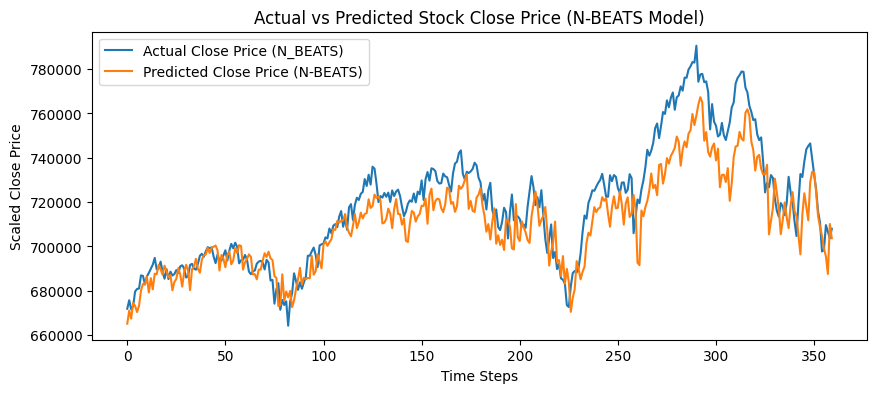

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y_true_nbeats3.flatten(), label="Actual Close Price (N_BEATS)")
plt.plot(y_pred_nbeats3.flatten(), label="Predicted Close Price (N-BEATS)")
plt.title("Actual vs Predicted Stock Close Price (N-BEATS Model)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.show()

# **ARIMA BASELINE WITHOUT SENTIMEN ANALYSIS**

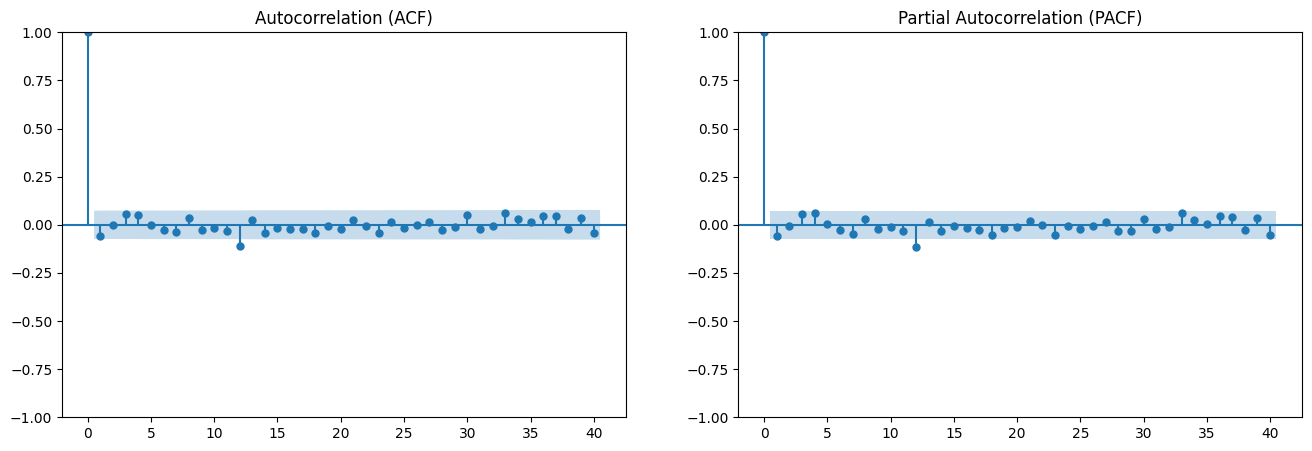

ARIMA(1,0,3) - SAME ORDER AS ARIMAX

Training ARIMA(1, 0, 3)...
                               SARIMAX Results                                
Dep. Variable:          target_scaled   No. Observations:                  236
Model:                 ARIMA(1, 0, 3)   Log Likelihood                 -65.149
Date:                Fri, 27 Feb 2026   AIC                            142.297
Time:                        16:11:19   BIC                            163.080
Sample:                             0   HQIC                           150.675
                                - 236                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1592      0.350     -0.455      0.649      -0.846       0.527
ar.L1          0.9348      0.027     34.695      0.000       0.882 

<Figure size 640x480 with 0 Axes>

Generating diagnostic plots...


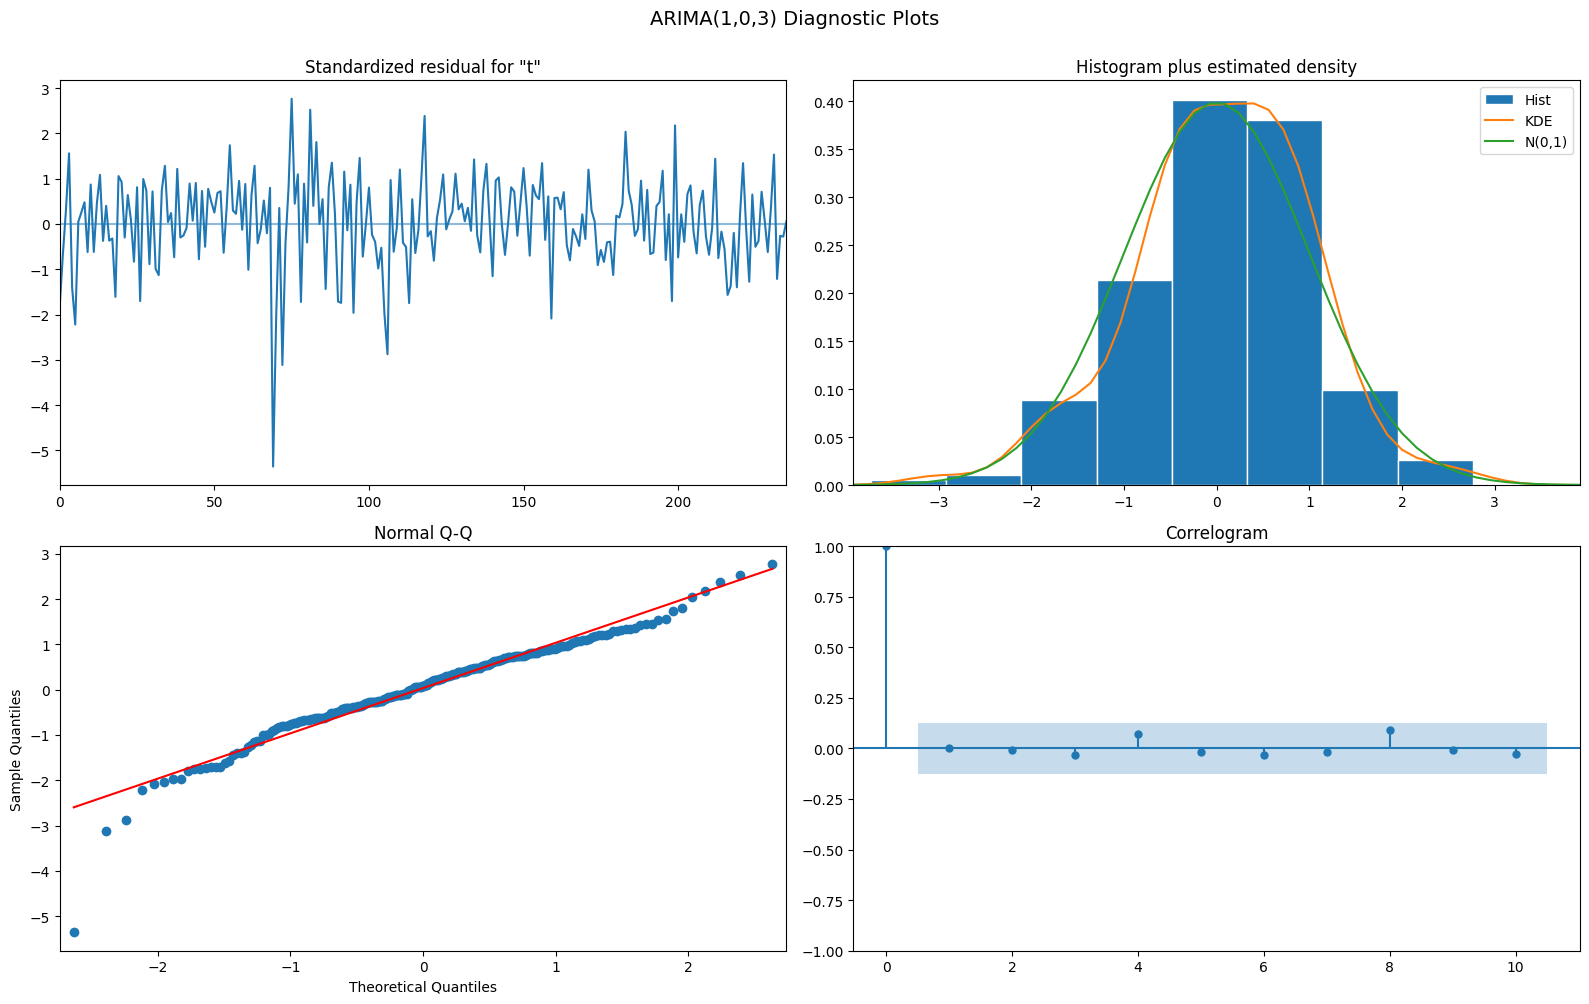


RESULTS SUMMARY
Model: ARIMA(1,0,3)
MAE: 4292.25
RMSE: 5548.62
MAPE: 0.60


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data_diff = df['Terakhir'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF
plot_acf(data_diff, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

# Plot PACF
plot_pacf(data_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.show()

features = feature_cols

y_train_sarimax = train_scaled['target_scaled']
X_train_sarimax = train_scaled[features]

y_val_sarimax = val_scaled['target_scaled']
X_val_sarimax = val_scaled[features]

y_test_sarimax = test_scaled['target_scaled']
X_test_sarimax = test_scaled[features]

print("="*60)
print("ARIMA(1,0,3) - SAME ORDER AS ARIMAX")
print("="*60)

best_order = (1,0,3)

print(f"\nTraining ARIMA{best_order}...")

model_arima = ARIMA(y_train_sarimax, order=best_order)
results_arima = model_arima.fit()

print(results_arima.summary())

print("\n" + "="*60)
print("Performing one-step ahead forecasting...")
print("="*60)

predictions_test_scaled = []

for i in range(len(y_test_sarimax)):
    if i == 0:
        current_model = results_arima
    else:
        updated_endog = pd.concat([y_train_sarimax, y_test_sarimax.iloc[:i]])

        model_updated = ARIMA(updated_endog, order=best_order)

        try:
            current_model = model_updated.fit(start_params=results_arima.params)
        except:
            current_model = model_updated.fit()

    pred_scaled = current_model.forecast(steps=1)
    predictions_test_scaled.append(pred_scaled.values[0])

    if (i + 1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(y_test_sarimax)}")

print(f"Forecasting: {len(predictions_test_scaled)} predictions")

pred_arima = scaler_y.inverse_transform(np.array(predictions_test_scaled).reshape(-1, 1))
y_true_arima = scaler_y.inverse_transform(y_test_sarimax.values.reshape(-1, 1))

mae_arima = mean_absolute_error(y_true_arima, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_true_arima, pred_arima))
mape_arima = np.mean(np.abs((y_true_arima - pred_arima) / y_true_arima)) * 100
mse_arima = mean_squared_error(y_true_arima, pred_arima)

print("\n" + "="*60)
print("ARIMA(2,1,2) PERFORMANCE (Test Set)")
print("="*60)
print(f"MAE  : {mae_arima:.2f}")
print(f"RMSE : {rmse_arima:.2f}")
print(f"MAPE : {mape_arima:.2f}%")
print(f"MSE  : {mse_arima:.2f}")

residuals = y_true_arima.flatten() - pred_arima.flatten()
axes[1].plot(residuals, label='Residuals', color='red', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].fill_between(range(len(residuals)), residuals, 0, alpha=0.3, color='red')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Prediction Residuals - Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Generating diagnostic plots...")
fig = results_arima.plot_diagnostics(figsize=(16, 10))
plt.suptitle('ARIMA(1,0,3) Diagnostic Plots', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

results_dict = {
    'Model': 'ARIMA(1,0,3)',
    'MAE': mae_arima,
    'RMSE': rmse_arima,
    'MAPE': mape_arima
}

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
for key, value in results_dict.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

#ACF/PACF Methods

In [34]:
features = feature_cols

y_train_arimax = train_scaled['target_scaled']
X_train_arimax = train_scaled[features]

y_val_arimax = val_scaled['target_scaled']
X_val_arimax = val_scaled[features]

y_test_arimax = test_scaled['target_scaled']
X_test_arimax = test_scaled[features]

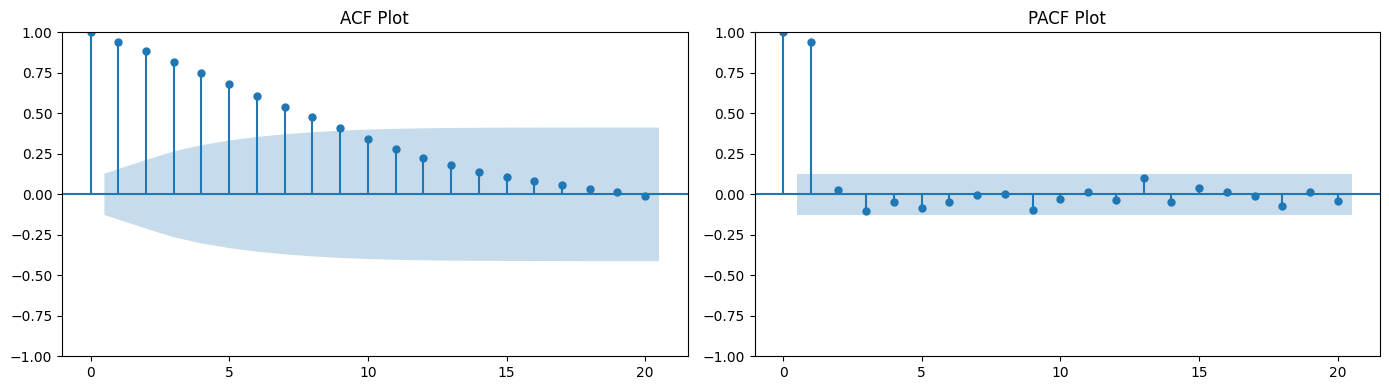

In [35]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = train_scaled['target_scaled']

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plot_acf(series, lags=20, ax=plt.gca())
plt.title("ACF Plot")

plt.subplot(1, 2, 2)
plot_pacf(series, lags=20, method='ywm', ax=plt.gca())
plt.title("PACF Plot")

plt.tight_layout()
plt.show()


## CANDIDATES FULL

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import acf, pacf

nlags = 20
acf_vals, acf_conf = acf(series, nlags=nlags, alpha=0.05)
pacf_vals, pacf_conf = pacf(series, nlags=nlags, alpha=0.05, method='ywm')

# Cari lag signifikan (di luar confidence interval)
q_candidates = np.where(
    (acf_conf[:, 0] > 0) | (acf_conf[:, 1] < 0))[0]

p_candidates = np.where(
    (pacf_conf[:, 0] > 0) | (pacf_conf[:, 1] < 0))[0]

# buang lag 0
q_candidates = q_candidates[q_candidates != 0]
p_candidates = p_candidates[p_candidates != 0]

print("Candidate q (from ACF) FULL:", q_candidates)
print("Candidate p (from PACF) FULL:", p_candidates)

Candidate q (from ACF) FULL: [1 2 3 4 5 6 7 8 9]
Candidate p (from PACF) FULL: [1]


In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Kandidat hasil ACF–PACF
p_candidates = [1]
d = 0
q_candidates = [1, 2, 3, 4, 5]

results = []

for p in p_candidates:
    for q in q_candidates:
        order = (p, d, q)
        try:
            model = ARIMA(
                endog=y_train_arimax,
                exog=X_train_arimax,
                order=order
            )
            fitted = model.fit()

            results.append({
                'p': p,
                'd': d,
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'HQIC': fitted.hqic
            })

            print(f"ARIMAX{order} | AIC: {fitted.aic:.2f}")

        except Exception as e:
            print(f"ARIMAX{order} failed")

results_df = pd.DataFrame(results)

results_sorted = (
    results_df
    .sort_values(by='AIC')
    .reset_index(drop=True)
)

print("\nRANKING ARIMAX MODELS (BASED ON AIC)")
print("="*60)
print(results_sorted)

ARIMAX(1, 0, 1) | AIC: 183.52
ARIMAX(1, 0, 2) | AIC: 185.14
ARIMAX(1, 0, 3) | AIC: 144.60
ARIMAX(1, 0, 4) | AIC: 160.95
ARIMAX(1, 0, 5) | AIC: 163.12

RANKING ARIMAX MODELS (BASED ON AIC)
   p  d  q         AIC         BIC        HQIC
0  1  0  3  144.598606  210.411410  171.128319
1  1  0  4  160.951255  230.227891  188.877268
2  1  0  5  163.116593  235.857061  192.438907
3  1  0  1  183.518746  242.403886  207.255857
4  1  0  2  185.142739  247.491711  210.276151


# **ARIMAX**


In [36]:
import numpy as np
from statsmodels.tsa.stattools import acf, pacf

nlags = 20
acf_vals, acf_conf = acf(series, nlags=nlags, alpha=0.05)
pacf_vals, pacf_conf = pacf(series, nlags=nlags, alpha=0.05, method='ywm')

# Cari lag signifikan (di luar confidence interval)
q_candidates = np.where(
    (acf_conf[:, 0] > 0) | (acf_conf[:, 1] < 0))[0]

p_candidates = np.where(
    (pacf_conf[:, 0] > 0) | (pacf_conf[:, 1] < 0))[0]

# buang lag 0
q_candidates = q_candidates[q_candidates != 0]
p_candidates = p_candidates[p_candidates != 0]

print("Candidate p (from PACF):", p_candidates[:5])
print("Candidate q (from ACF):", q_candidates[:5])

Candidate p (from PACF): [1]
Candidate q (from ACF): [1 2 3 4 5]


In [37]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Kandidat hasil ACF–PACF
p_candidates = [1]
d = 0
q_candidates = [1, 2, 3, 4, 5]

results = []

for p in p_candidates:
    for q in q_candidates:
        order = (p, d, q)
        try:
            model = ARIMA(
                endog=y_train_arimax,
                exog=X_train_arimax,
                order=order
            )
            fitted = model.fit()

            results.append({
                'p': p,
                'd': d,
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'HQIC': fitted.hqic
            })

            print(f"ARIMAX{order} | AIC: {fitted.aic:.2f}")

        except Exception as e:
            print(f"ARIMAX{order} failed")

results_df = pd.DataFrame(results)

results_sorted = (
    results_df
    .sort_values(by='AIC')
    .reset_index(drop=True)
)

print("\nRANKING ARIMAX MODELS (BASED ON AIC)")
print("="*60)
print(results_sorted)

ARIMAX(1, 0, 1) | AIC: 183.52
ARIMAX(1, 0, 2) | AIC: 185.14
ARIMAX(1, 0, 3) | AIC: 144.60
ARIMAX(1, 0, 4) | AIC: 160.95
ARIMAX(1, 0, 5) | AIC: 163.12

RANKING ARIMAX MODELS (BASED ON AIC)
   p  d  q         AIC         BIC        HQIC
0  1  0  3  144.598606  210.411410  171.128319
1  1  0  4  160.951255  230.227891  188.877268
2  1  0  5  163.116593  235.857061  192.438907
3  1  0  1  183.518746  242.403886  207.255857
4  1  0  2  185.142739  247.491711  210.276151


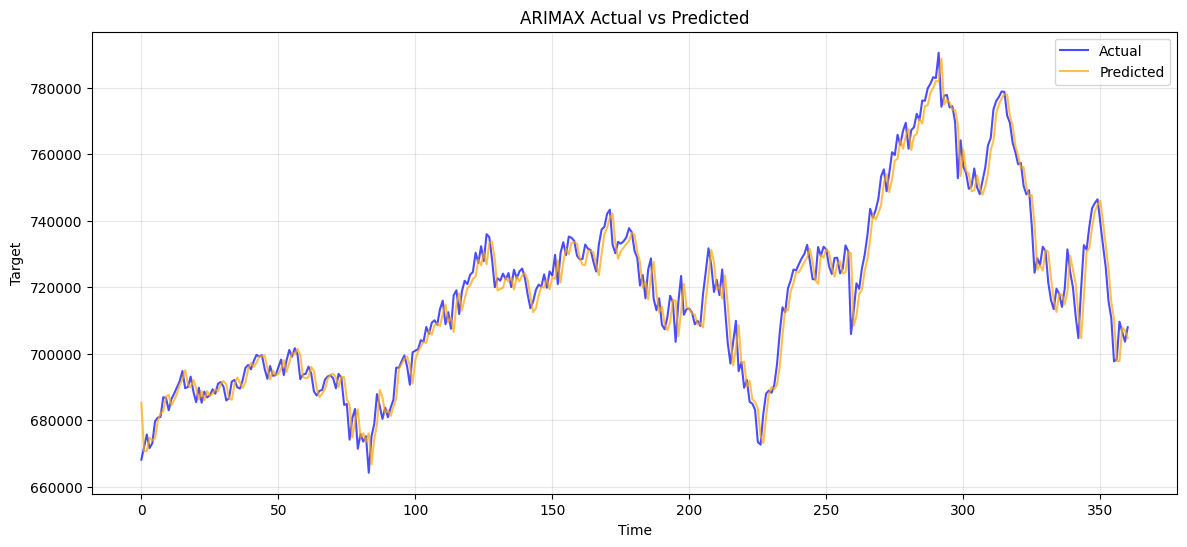

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_true_arima, label='Actual', color='blue', alpha=0.7)
plt.plot(pred_arima, label='Predicted', color='orange', alpha=0.7)
plt.title('ARIMAX Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Target')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [39]:
from statsmodels.tsa.arima.model import ARIMA

order = (1, 0, 3)

model_arimax = ARIMA(
    endog=y_train_arimax,
    exog=X_train_arimax,
    order=order
)

results_arimax = model_arimax.fit()
print(results_arimax.summary())

                               SARIMAX Results                                
Dep. Variable:          target_scaled   No. Observations:                  236
Model:                 ARIMA(1, 0, 3)   Log Likelihood                 -53.299
Date:                Fri, 27 Feb 2026   AIC                            144.599
Time:                        16:15:32   BIC                            210.411
Sample:                             0   HQIC                           171.128
                                - 236                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0242      0.118     -0.205      0.838      -0.256       0.207
Pembukaan        -0.1491      0.163     -0.913      0.361      -0.469       0.171
Tertinggi        -0.1274      0.144     

In [40]:
import numpy as np

predictions_scaled = []

for i in range(len(y_test_arimax)):
    if i == 0:
        current_model = results_arimax
        pred = current_model.forecast(
            steps=1,
            exog=X_test_arimax.iloc[[i]]
        )
    else:
        updated_y = pd.concat([y_train_arimax, y_test_arimax.iloc[:i]])
        updated_X = pd.concat([X_train_arimax, X_test_arimax.iloc[:i]])

        model_updated = ARIMA(
            endog=updated_y,
            exog=updated_X,
            order=order
        )
        current_model = model_updated.fit()
        pred = current_model.forecast(
            steps=1,
            exog=X_test_arimax.iloc[[i]]
        )

    predictions_scaled.append(pred.values[0])

pred_scaled = np.array(predictions_scaled).reshape(-1, 1)

pred_arimax = scaler_y.inverse_transform(pred_scaled)
y_true_arimax = scaler_y.inverse_transform(
    y_test_arimax.values.reshape(-1, 1))

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_arimax  = mean_absolute_error(y_true_arimax, pred_arimax)
mse_arimax  = mean_squared_error(y_true_arimax, pred_arimax)
rmse_arimax = np.sqrt(mse_arimax)
mape_arimax = np.mean(
    np.abs((y_true_arimax - pred_arimax) / y_true_arimax)
) * 100

print("ARIMAX Performance:")
print(f"MAE  : {mae_arimax:.4f}")
print(f"MSE  : {mse_arimax:.4f}")
print(f"RMSE : {rmse_arimax:.4f}")
print(f"MAPE : {mape_arimax:.2f}%")

ARIMAX Performance:
MAE  : 4379.7343
MSE  : 31868408.7335
RMSE : 5645.2111
MAPE : 0.61%


In [41]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = results_arimax.resid

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10, 20],
    return_df=True)

print(ljung_box)

      lb_stat  lb_pvalue
10   3.964538   0.948933
20  15.512852   0.746349


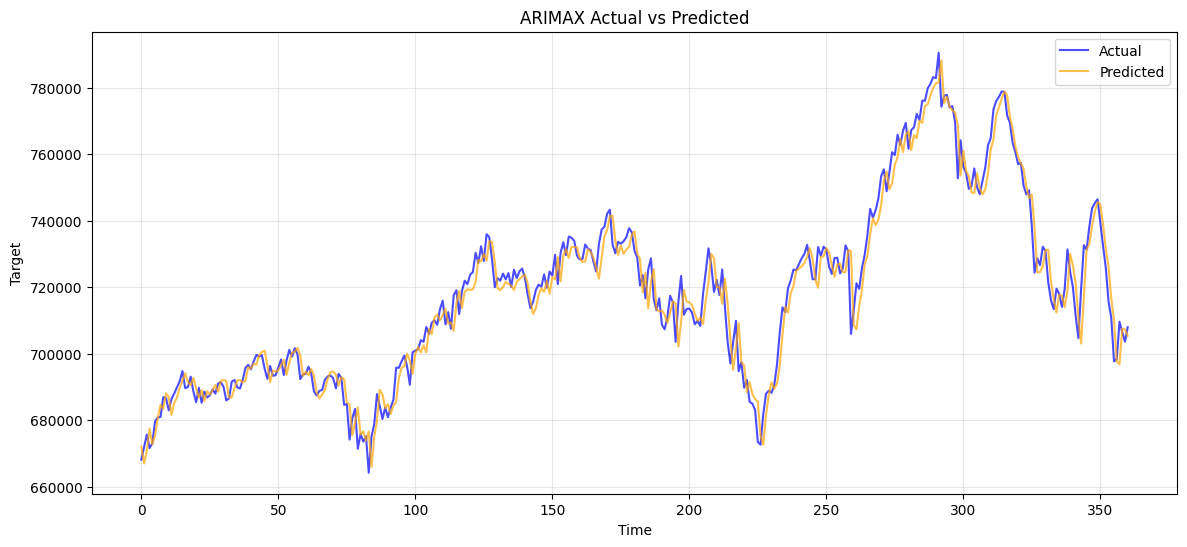

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_true_arimax, label='Actual', color='blue', alpha=0.7)
plt.plot(pred_arimax, label='Predicted', color='orange', alpha=0.7)
plt.title('ARIMAX Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Target')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Comparison Model**

In [48]:
lstm_mae_val = best['test_mae']
lstm_mse_val = best['test_mse']
lstm_rmse_val = best['test_rmse']
lstm_mape_val = best['test_mape']

nbeats_mae_val = mae_nbeats3
nbeats_mse_val = mse_nbeats3
nbeats_rmse_val = rmse_nbeats3
nbeats_mape_val = mape_nbeats3

arima_mae_val = mae_arima
arima_mse_val = mse_arima
arima_rmse_val = rmse_arima
arima_mape_val = mape_arima

arimax_mae_val = mae_arimax
arimax_mse_val = mse_arimax
arimax_rmse_val = rmse_arimax
arimax_mape_val = mape_arimax

metrics_data = {
    'Model': ['LSTM', 'N-BEATS', 'ARIMA', 'ARIMAX'],
    'MSE': [lstm_mse_val, nbeats_mse_val, arima_mse_val, arimax_mse_val],
    'RMSE': [lstm_rmse_val, nbeats_rmse_val, arima_rmse_val, arimax_rmse_val],
    'MAE': [lstm_mae_val, nbeats_mae_val, arima_mae_val, arimax_mae_val],
    'MAPE': [lstm_mape_val, nbeats_mape_val, arima_mape_val, arimax_mape_val],
}

df_metrics = pd.DataFrame(metrics_data)

df_metrics_sorted = df_metrics.sort_values(by='MAPE').reset_index(drop=True)
df_metrics_sorted['Rank'] = df_metrics_sorted.index + 1

print('Model Performance Metrics (Sorted by MAPE):')
print(df_metrics_sorted)

output_filename = 'model_comparison_metrics.csv'
df_metrics_sorted.to_csv(output_filename, index=False)

print(f'Model metrics saved to {output_filename}')

Model Performance Metrics (Sorted by MAPE):
     Model           MSE          RMSE           MAE      MAPE  Rank
0    ARIMA  3.078719e+07   5548.620664   4292.247080  0.597397     1
1   ARIMAX  3.186841e+07   5645.211133   4379.734311  0.609609     2
2  N-BEATS  1.792319e+08  13387.752361  10506.371007  1.436066     3
3     LSTM  2.656474e+08  16298.693686  12065.218924  1.635863     4
Model metrics saved to model_comparison_metrics.csv


In [49]:
import joblib

joblib.dump(results_arimax, 'best_arimax_model.joblib')
print("Best ARIMAX model saved as 'best_aarimax_model.joblib'")

Best ARIMAX model saved as 'best_aarimax_model.joblib'


# **Uji Granger Causality**

In [ ]:
from statsmodels.tsa.api import VAR

data_gc = df[['return', 'avg_sentiment']].dropna()
model = VAR(data_gc)
lag_order_results = model.select_order(maxlags=15)

print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -11.14     -11.12*   1.459e-05     -11.13*
1      -11.14*      -11.10  1.446e-05*      -11.13
2       -11.14      -11.07   1.458e-05      -11.11
3       -11.13      -11.04   1.464e-05      -11.10
4       -11.13      -11.01   1.467e-05      -11.08
5       -11.12      -10.98   1.474e-05      -11.07
6       -11.11      -10.94   1.489e-05      -11.05
7       -11.11      -10.91   1.499e-05      -11.03
8       -11.11      -10.89   1.499e-05      -11.02
9       -11.10      -10.85   1.512e-05      -11.00
10      -11.09      -10.82   1.520e-05      -10.99
11      -11.08      -10.78   1.536e-05      -10.97
12      -11.09      -10.77   1.523e-05      -10.97
13      -11.09      -10.74   1.524e-05      -10.96
14      -11.08      -10.70   1.538e-05      -10.94
15      -11.08      -10.67   1.547e-05      -10.92
-------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

granger_result = grangercausalitytests(
    df[['return', 'avg_sentiment']],
    maxlag=1
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5805  , p=0.4464  , df_denom=708, df_num=1
ssr based chi2 test:   chi2=0.5830  , p=0.4451  , df=1
likelihood ratio test: chi2=0.5827  , p=0.4452  , df=1
parameter F test:         F=0.5805  , p=0.4464  , df_denom=708, df_num=1


In [ ]:
from statsmodels.tsa.api import VAR

data_gc = df[['Terakhir', 'avg_sentiment']].dropna()
model = VAR(data_gc)
lag_order_results = model.select_order(maxlags=15)

print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        19.00       19.01   1.779e+08       19.00
1        15.79      15.83*   7.225e+06      15.81*
2       15.79*       15.86  7.203e+06*       15.82
3        15.80       15.89   7.257e+06       15.83
4        15.80       15.92   7.271e+06       15.84
5        15.80       15.94   7.269e+06       15.85
6        15.81       15.98   7.334e+06       15.87
7        15.82       16.01   7.402e+06       15.89
8        15.82       16.04   7.413e+06       15.90
9        15.82       16.07   7.440e+06       15.92
10       15.83       16.11   7.517e+06       15.94
11       15.84       16.14   7.572e+06       15.96
12       15.85       16.17   7.617e+06       15.97
13       15.84       16.19   7.554e+06       15.97
14       15.84       16.22   7.599e+06       15.99
15       15.85       16.26   7.663e+06       16.01
-------------------------------

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

granger_result = grangercausalitytests(
    df[['Terakhir', 'avg_sentiment']],
    maxlag=2
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.4561  , p=0.4997  , df_denom=708, df_num=1
ssr based chi2 test:   chi2=0.4580  , p=0.4986  , df=1
likelihood ratio test: chi2=0.4579  , p=0.4986  , df=1
parameter F test:         F=0.4561  , p=0.4997  , df_denom=708, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7334  , p=0.4807  , df_denom=705, df_num=2
ssr based chi2 test:   chi2=1.4771  , p=0.4778  , df=2
likelihood ratio test: chi2=1.4756  , p=0.4782  , df=2
parameter F test:         F=0.7334  , p=0.4807  , df_denom=705, df_num=2
